# Sondertilgung vs ETF: Mortgage Extra Repayment Comparison

This notebook compares strategies for the same mortgage with varying Sondertilgung rates (0%, 1%, 2%, 3%, 4%, 5% of original loan per year):

- **0%**: Pay only mandatory monthly mortgage payments, invest all surplus into ETF
- **1-5%**: Make annual extra repayments (penalty-free), invest the remainder into ETF

All scenarios have the same total cash flow (income, spending). The only difference is how surplus cash is allocated between Sondertilgung and ETF.

**Trade-off**: Sondertilgung gives a guaranteed return equal to the mortgage rate (saved interest) and frees up the mortgage payment sooner, while ETF yields a higher expected return but with risk.

In [26]:
from pathlib import Path
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

ROOT_DIR = Path("/Users/pkoshkin/code/personal/finantial-tools")
import sys
sys.path.append(str(ROOT_DIR))

from src.buy_vs_rent import compute_finantial_model, calculate_early_repayment_penalty

## Parameters

In [27]:
# Mortgage parameters
APARTMENT_PRICE = 450_000
MORTGAGE_INTEREST_RATE = 3.80 / 100
MORTGAGE_DOWN_PAYMENT_RATE = 10 / 100
MORTGAGE_TOTAL_FEES_RATE = 10 / 100
MORTGAGE_YEARLY_REPAYMENT_RATE = 1.5 / 100
MORTGAGE_REFINANCING_YEARS = 10

# Sondertilgung: max 5% of original loan per year without penalty
SONDERTILGUNG_YEARLY_RATE = 5 / 100

# ETF returns
ETF_YEARLY_RETURN_RATE = 7 / 100

# Cash flow
INITIAL_CAPITAL = 100_000
MONTHLY_NET_INCOME = 5_000
MONTHLY_SPENDING = 2_000
YEARLY_INCOME_INCREASE_RATE = 2 / 100
YEARLY_INFLATION_RATE = 2 / 100

# Property appreciation
YEARLY_APARTMENT_RAISE_RATE = 3 / 100

# No rent (own apartment)
COLD_RENT_MONTHLY = 0
COLD_RENT_YEARLY_INCREASE_RATE = 0

# Simulation
YEARS = 30

# Derived values for reference
LOAN_AMOUNT = APARTMENT_PRICE * (1 - MORTGAGE_DOWN_PAYMENT_RATE)
MONTHLY_PAYMENT = LOAN_AMOUNT * (MORTGAGE_INTEREST_RATE + MORTGAGE_YEARLY_REPAYMENT_RATE) / 12
MAX_SONDERTILGUNG = LOAN_AMOUNT * SONDERTILGUNG_YEARLY_RATE

print(f"Loan amount: {LOAN_AMOUNT:,.0f} EUR")
print(f"Monthly payment: {MONTHLY_PAYMENT:,.2f} EUR")
print(f"Max Sondertilgung per year: {MAX_SONDERTILGUNG:,.0f} EUR")
print(f"Sondertilgung monthly reserve: {MAX_SONDERTILGUNG/12:,.2f} EUR")

Loan amount: 405,000 EUR
Monthly payment: 1,788.75 EUR
Max Sondertilgung per year: 20,250 EUR
Sondertilgung monthly reserve: 1,687.50 EUR


## Run Models

In [28]:
common_params = dict(
    yearly_inflation_rate=YEARLY_INFLATION_RATE,
    yearly_apartment_raise_rate=YEARLY_APARTMENT_RAISE_RATE,
    mortgage_apartment_price=APARTMENT_PRICE,
    mortgage_interest_rate=MORTGAGE_INTEREST_RATE,
    mortgage_down_payment_rate=MORTGAGE_DOWN_PAYMENT_RATE,
    mortgage_total_fees_rate=MORTGAGE_TOTAL_FEES_RATE,
    mortgage_yearly_repayment_rate=MORTGAGE_YEARLY_REPAYMENT_RATE,
    mortgate_refinancing_years=MORTGAGE_REFINANCING_YEARS,
    etf_yearly_return_rate=ETF_YEARLY_RETURN_RATE,
    cold_rent_monthly_cost=COLD_RENT_MONTHLY,
    cold_rent_yearly_increase_rate=COLD_RENT_YEARLY_INCREASE_RATE,
    initial_capital=INITIAL_CAPITAL,
    monthly_net_income=MONTHLY_NET_INCOME,
    monthly_spending=MONTHLY_SPENDING,
    yearly_income_increase_rate=YEARLY_INCOME_INCREASE_RATE,
    years=YEARS,
)

SONDERTILGUNG_RATES_PCT = [0, 1, 2, 3, 4, 5]

scenarios = {}
for pct in SONDERTILGUNG_RATES_PCT:
    scenarios[pct] = compute_finantial_model(
        **common_params, sondertilgung_yearly_rate=pct / 100
    )

print(f"Computed {len(scenarios)} scenarios: {SONDERTILGUNG_RATES_PCT}% Sondertilgung")

Computed 6 scenarios: [0, 1, 2, 3, 4, 5]% Sondertilgung


## Results Tables

In [29]:
display_cols = [
    'year', 'total_loan', 'etf_capital', 'estimated_total_capital',
    'monthly_apartment_spend', 'monthly_leftover',
    'yearly_sondertilgung', 'cumulative_interest_paid',
]

for pct in SONDERTILGUNG_RATES_PCT:
    print("=" * 80)
    print(f"Sondertilgung: {pct}%")
    print("=" * 80)
    display(scenarios[pct][display_cols])

Sondertilgung: 0%


,year,total_loan,etf_capital,estimated_total_capital,monthly_apartment_spend,monthly_leftover,yearly_sondertilgung,cumulative_interest_paid
0,0,0.000000,1.000000e+05,1.000000e+05,0.000000,3000.000000,0.0,0.000000
1,1,398818.068908,2.547224e+04,9.015418e+04,1788.750000,1174.613670,0.0,15283.068908
2,2,392397.089531,4.276590e+04,1.277738e+05,1788.750000,1233.880944,0.0,30327.089531
3,3,385727.818140,6.202322e+04,1.680226e+05,1788.750000,1294.333563,0.0,45122.818140
4,4,378800.653565,8.339674e+04,2.110750e+05,1788.750000,1355.995234,0.0,59660.653565
5,5,371605.623369,1.070499e+05,2.571177e+05,1788.750000,1418.890139,0.0,73930.623369
6,6,364132.369489,1.331581e+05,3.063492e+05,1788.750000,1483.042941,0.0,87922.369489
7,7,356370.133331,1.619090e+05,3.589821e+05,1788.750000,1548.478800,0.0,101625.133331
8,8,348307.740277,1.935040e+05,4.152428e+05,1788.750000,1615.223376,0.0,115027.740277
9,9,339933.583599,2.281587e+05,4.753731e+05,1788.750000,1683.302844,0.0,128118.583599


Sondertilgung: 1%


,year,total_loan,etf_capital,estimated_total_capital,monthly_apartment_spend,monthly_leftover,yearly_sondertilgung,cumulative_interest_paid
0,0,0.000000,1.000000e+05,1.000000e+05,0.000000,3000.000000,0.0,0.000000
1,1,394768.068908,2.129389e+04,9.002583e+04,1788.750000,1174.613670,4050.0,15283.068908
2,2,384140.480610,3.411671e+04,1.273812e+05,1788.750000,1233.880944,4050.0,30170.480610
3,3,373101.935487,4.859024e+04,1.672155e+05,1788.750000,1294.333563,4050.0,44646.935487
4,4,361636.542305,6.484510e+04,2.096875e+05,1788.750000,1355.995234,4050.0,58696.542305
5,5,349727.795332,8.302134e+04,2.549669e+05,1788.750000,1418.890139,4050.0,72302.795332
6,6,337358.550578,1.032691e+05,3.032341e+05,1788.750000,1483.042941,4050.0,85448.550578
7,7,324511.001114,1.257495e+05,3.546817e+05,1788.750000,1548.478800,4050.0,98116.001114
8,8,311166.651437,1.506349e+05,4.095148e+05,1788.750000,1615.223376,4050.0,110286.651437
9,9,297306.290847,1.781105e+05,4.679521e+05,1788.750000,1683.302844,4050.0,121941.290847


Sondertilgung: 2%


...

,year,total_loan,etf_capital,estimated_total_capital,monthly_apartment_spend,monthly_leftover,yearly_sondertilgung,cumulative_interest_paid
0,0,0.000000,1.000000e+05,1.000000e+05,0.000000,3000.000000,0.000000,0.000000
1,1,386668.068908,1.293719e+04,8.976912e+04,1788.750000,1174.613670,12150.000000,15283.068908
2,2,367627.262768,1.681834e+04,1.265961e+05,1788.750000,1233.880944,12150.000000,29857.262768
3,3,347850.170182,2.172429e+04,1.656013e+05,1788.750000,1294.333563,12150.000000,43695.170182
4,4,327308.319785,2.774183e+04,2.069125e+05,1788.750000,1355.995234,12150.000000,56768.319785
5,5,305972.139260,3.496414e+04,2.506653e+05,1788.750000,1418.890139,12150.000000,69047.139260
6,6,283810.912756,4.349122e+04,2.970038e+05,1788.750000,1483.042941,12150.000000,80500.912756
7,7,260792.736679,5.343040e+04,3.460809e+05,1788.750000,1548.478800,12150.000000,91097.736679
8,8,236884.473758,6.489683e+04,3.980589e+05,1788.750000,1615.223376,12150.000000,100804.473758
9,9,212051.705342,7.801403e+04,4.531103e+05,1788.750000,1683.302844,12150.000000,109586.705342


Sondertilgung: 4%


,year,total_loan,etf_capital,estimated_total_capital,monthly_apartment_spend,monthly_leftover,yearly_sondertilgung,cumulative_interest_paid
0,0,0.000000,1.000000e+05,1.000000e+05,0.000000,3000.000000,0.000000,0.000000
1,1,382618.068908,8.758843e+03,8.964077e+04,1788.750000,1174.613670,16200.000000,15283.068908
2,2,359370.653847,8.169156e+03,1.262035e+05,1788.750000,1233.880944,16200.000000,29700.653847
3,3,335224.287529,8.291307e+03,1.647942e+05,1788.750000,1294.333563,16200.000000,43219.287529
4,4,310144.208525,9.190188e+03,2.055249e+05,1788.750000,1355.995234,16200.000000,55804.208525
5,5,284094.311223,1.093553e+04,2.485146e+05,1788.750000,1418.890139,16200.000000,67419.311223
6,6,257037.093845,1.360227e+04,2.938887e+05,1788.750000,1483.042941,16200.000000,78027.093845
7,7,228933.604462,1.727087e+04,3.417805e+05,1788.750000,1548.478800,16200.000000,87588.604462
8,8,199743.384919,2.202778e+04,3.923309e+05,1788.750000,1615.223376,16200.000000,96063.384919
9,9,169424.412589,2.796580e+04,4.456893e+05,1788.750000,1683.302844,16200.000000,103409.412589


Sondertilgung: 5%


,year,total_loan,etf_capital,estimated_total_capital,monthly_apartment_spend,monthly_leftover,yearly_sondertilgung,cumulative_interest_paid
0,0,0.000000,1.000000e+05,1.000000e+05,0.000000,3000.000000,0.000000,0.000000
1,1,378568.068908,4.580493e+03,8.951242e+04,1788.750000,1174.613670,20250.000000,15283.068908
2,2,351114.044926,-4.800294e+02,1.258109e+05,1788.750000,1233.880944,20250.000000,29544.044926
3,3,322598.404876,-5.141671e+03,1.639871e+05,1788.750000,1294.333563,20250.000000,42743.404876
4,4,292980.097265,-9.361449e+03,2.041374e+05,1788.750000,1355.995234,20250.000000,54840.097265
5,5,262216.483187,-1.309307e+04,2.463638e+05,1788.750000,1418.890139,20250.000000,65791.483187
6,6,230263.274934,-1.628669e+04,2.907736e+05,1788.750000,1483.042941,20250.000000,75553.274934
7,7,197074.472245,-1.888866e+04,3.374801e+05,1788.750000,1548.478800,20250.000000,84079.472245
8,8,162602.296079,-2.084127e+04,3.866030e+05,1788.750000,1615.223376,20250.000000,91322.296079
9,9,126797.119836,-2.208243e+04,4.382684e+05,1788.750000,1683.302844,20250.000000,97232.119836


## Comparison Plots

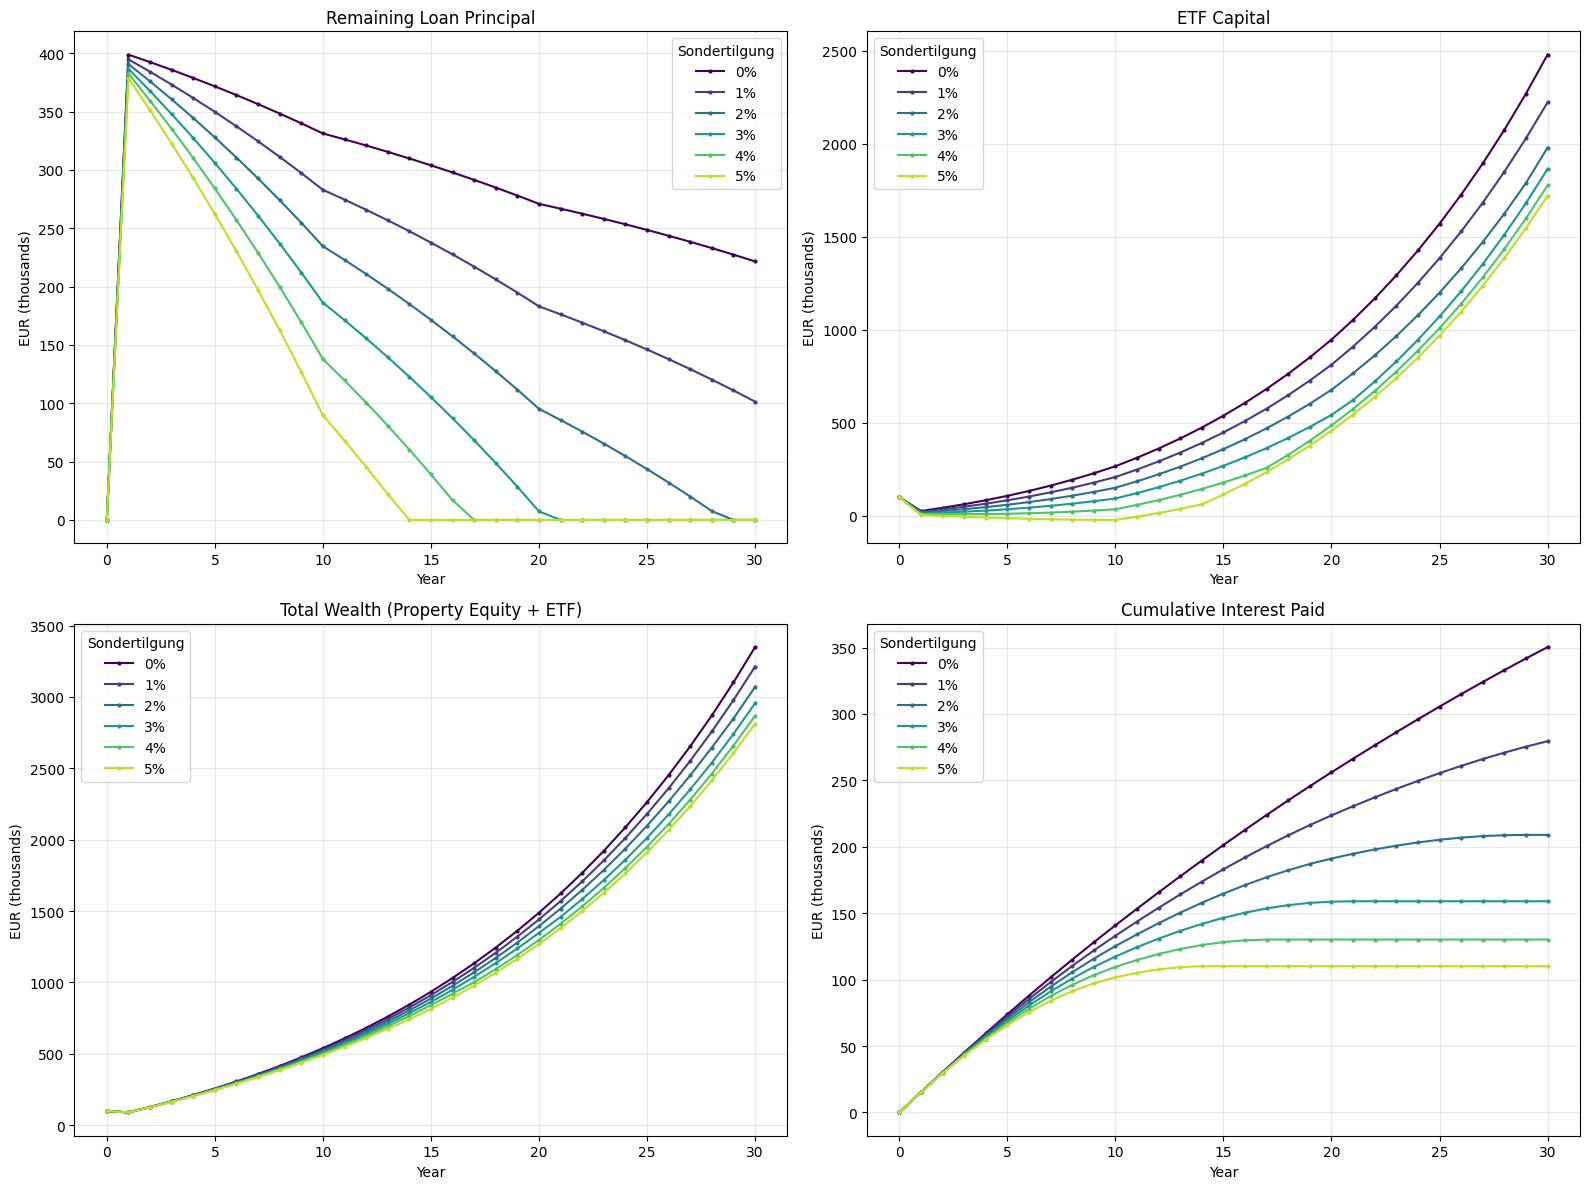

In [30]:
years = scenarios[0]['year']
colors = plt.cm.viridis(np.linspace(0, 0.9, len(SONDERTILGUNG_RATES_PCT)))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for pct, color in zip(SONDERTILGUNG_RATES_PCT, colors):
    df = scenarios[pct]
    label = f'{pct}%'

    axes[0, 0].plot(years, df['total_loan'] / 1000, '-o', markersize=2, color=color, label=label)
    axes[0, 1].plot(years, df['etf_capital'] / 1000, '-o', markersize=2, color=color, label=label)
    axes[1, 0].plot(years, df['estimated_total_capital'] / 1000, '-o', markersize=2, color=color, label=label)
    axes[1, 1].plot(years, df['cumulative_interest_paid'] / 1000, '-o', markersize=2, color=color, label=label)

titles = ['Remaining Loan Principal', 'ETF Capital',
          'Total Wealth (Property Equity + ETF)', 'Cumulative Interest Paid']
for ax, title in zip(axes.flat, titles):
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel('EUR (thousands)')
    ax.legend(title='Sondertilgung')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

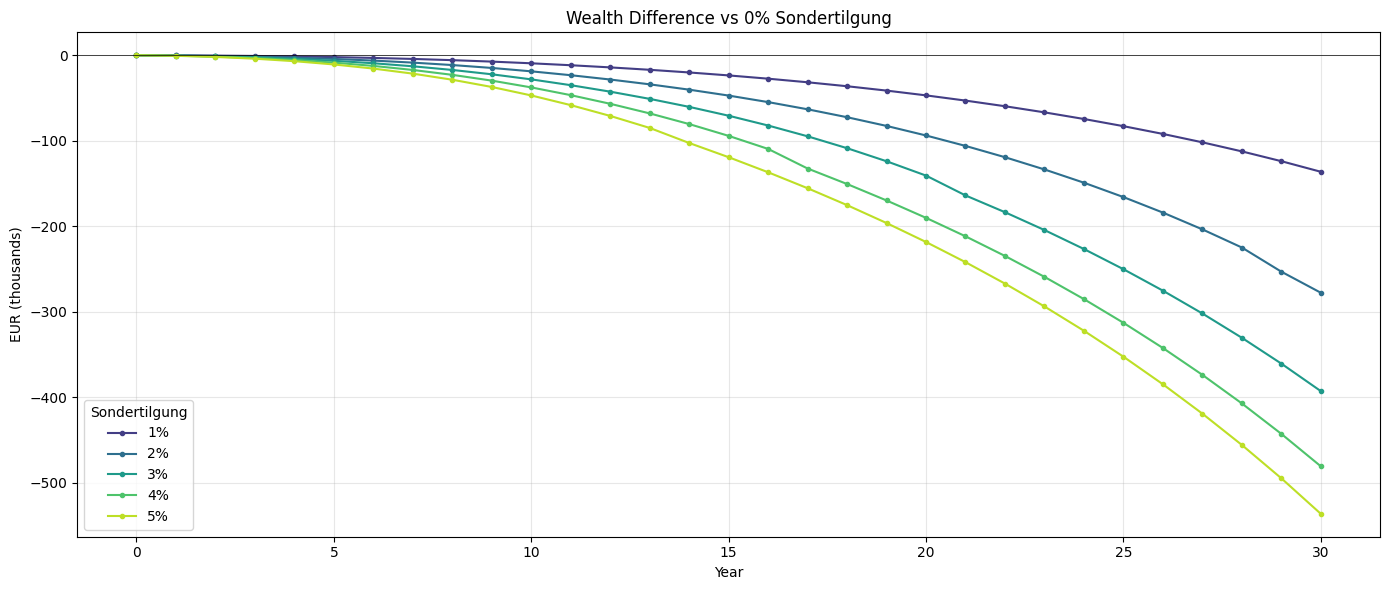

In [31]:
# Wealth difference over time vs 0% baseline
baseline = scenarios[0]['estimated_total_capital']

fig, ax = plt.subplots(figsize=(14, 6))
for pct, color in zip(SONDERTILGUNG_RATES_PCT[1:], colors[1:]):
    diff = scenarios[pct]['estimated_total_capital'] - baseline
    ax.plot(years, diff / 1000, '-o', markersize=3, color=color, label=f'{pct}%')

ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Wealth Difference vs 0% Sondertilgung')
ax.set_xlabel('Year')
ax.set_ylabel('EUR (thousands)')
ax.legend(title='Sondertilgung')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary Metrics

In [32]:
def find_payoff_year(df):
    paid_off = df[(df['year'] > 0) & (df['total_loan'] <= 0)]
    return int(paid_off['year'].iloc[0]) if not paid_off.empty else None

summary_rows = []
for pct in SONDERTILGUNG_RATES_PCT:
    df = scenarios[pct]
    summary_rows.append({
        'sondertilgung_%': pct,
        'total_interest': df['cumulative_interest_paid'].iloc[-1],
        'interest_savings_vs_0%': scenarios[0]['cumulative_interest_paid'].iloc[-1] - df['cumulative_interest_paid'].iloc[-1],
        'payoff_year': find_payoff_year(df),
        'final_wealth': df['estimated_total_capital'].iloc[-1],
        'wealth_diff_vs_0%': df['estimated_total_capital'].iloc[-1] - scenarios[0]['estimated_total_capital'].iloc[-1],
        'total_sondertilgung': df['yearly_sondertilgung'].sum(),
    })

summary = pd.DataFrame(summary_rows)
summary['payoff_year'] = summary['payoff_year'].apply(lambda x: x if x else f'>{YEARS}')

print("=" * 100)
print(f"COMPARISON SUMMARY (mortgage rate: {MORTGAGE_INTEREST_RATE*100:.2f}%, ETF: {ETF_YEARLY_RETURN_RATE*100:.1f}%, horizon: {YEARS} years)")
print("=" * 100)
for col in ['total_interest', 'interest_savings_vs_0%', 'final_wealth', 'wealth_diff_vs_0%', 'total_sondertilgung']:
    summary[col] = summary[col].map('{:,.0f}'.format)
display(summary)

COMPARISON SUMMARY (mortgage rate: 3.80%, ETF: 7.0%, horizon: 30 years)


,sondertilgung_%,total_interest,interest_savings_vs_0%,payoff_year,final_wealth,wealth_diff_vs_0%,total_sondertilgung
0,0,"350,350",0,NaN,"3,348,986",0,0
1,1,"279,503","70,848",NaN,"3,212,658","-136,328","121,500"
2,2,"208,950","141,400",29.0,"3,071,108","-277,879","229,557"
3,3,"159,002","191,348",21.0,"2,956,006","-392,981","250,245"
4,4,"130,158","220,193",17.0,"2,868,045","-480,941","269,334"
5,5,"110,137","240,213",14.0,"2,812,434","-536,552","281,490"


## Early Repayment Penalty Analysis (Vorfälligkeitsentschädigung)

If you sell the apartment before the Zinsbindung period ends, the bank charges a penalty. After 10 years, penalty = 0 (with 6 months notice).

In [33]:
MARKET_RATE = 3.0 / 100
ZINSBINDUNG_YEARS = MORTGAGE_REFINANCING_YEARS

penalty_rows = []
for year in range(1, ZINSBINDUNG_YEARS + 1):
    remaining_years = ZINSBINDUNG_YEARS - year
    for pct in SONDERTILGUNG_RATES_PCT:
        df = scenarios[pct]
        row = df[df['year'] == year].iloc[0]
        balance = row['total_loan']
        penalty = calculate_early_repayment_penalty(
            remaining_principal=balance,
            loan_rate=MORTGAGE_INTEREST_RATE,
            market_rate=MARKET_RATE,
            remaining_years=remaining_years,
        )
        penalty_rows.append({
            'year': year,
            'sondertilgung_%': pct,
            'remaining_loan': balance,
            'penalty': penalty,
            'total_exit_cost': balance + penalty,
        })

penalty_df = pd.DataFrame(penalty_rows)
print(f"Assumed market rate for penalty calculation: {MARKET_RATE*100:.1f}%")
print(f"Loan rate: {MORTGAGE_INTEREST_RATE*100:.2f}%")
print(f"Zinsbindung: {ZINSBINDUNG_YEARS} years")
print()

pivot = penalty_df.pivot_table(
    index='year',
    columns='sondertilgung_%',
    values='total_exit_cost',
)
pivot.columns = [f'{c}%' for c in pivot.columns]
display(pivot.map('{:,.0f}'.format))

Assumed market rate for penalty calculation: 3.0%
Loan rate: 3.80%
Zinsbindung: 10 years



,0%,1%,2%,3%,4%,5%
year,,,,,,
1,"427,533","423,191","418,850","414,508","410,167","405,825"
2,"417,511","408,725","399,940","391,155","382,370","373,585"
3,"407,329","393,996","380,663","367,330","353,997","340,664"
4,"396,983","378,995","361,007","343,019","325,031","307,043"
5,"386,470","363,717","340,964","318,211","295,458","272,705"
6,"375,785","348,154","320,523","292,893","265,262","237,632"
7,"364,923","332,299","299,676","267,052","234,428","201,804"
8,"353,881","316,145","278,410","240,675","202,939","165,204"
9,"342,653","299,685","256,716","213,748","170,780","127,811"
